In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os


json_file = "/content/drive/MyDrive/Colab Notebooks/photos.json"
data_path = "/content/drive/MyDrive/Colab Notebooks/photos"

# Check if files exist
print("JSON File Exists:", os.path.exists(json_file))
print("Photos Folder Exists:", os.path.exists(data_path))


JSON File Exists: True
Photos Folder Exists: True


In [ ]:
import json
import os
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Directory path to your images
PHOTO_DIR = "/content/drive/MyDrive/Colab Notebooks/photos"
PHOTO_JSON = "/content/drive/MyDrive/Colab Notebooks/photos.json"

# Create a transformation for resizing and normalizing the images (keeping them in RGB)
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # Normalize to [-1, 1] for RGB
])

# Function to load photo_id to category mapping from JSON file
def load_photo_categories(json_file):
    photo_to_category = {}

    with open(json_file, 'r') as f:
        for line in f:
            try:
                # Parse each line as a separate JSON object
                data = json.loads(line)
                # Map photo_id to its corresponding category (label)
                if 'photo_id' in data and 'label' in data:
                    photo_to_category[data['photo_id']] = data['label']
            except json.JSONDecodeError:
                continue  # Skip any invalid lines

    return photo_to_category

# Load photo_id to category mapping
photo_to_category = load_photo_categories(PHOTO_JSON)

# Check how many files are in the directory and print a few file names
all_files = os.listdir(PHOTO_DIR)
print(f"Total files in the directory: {len(all_files)}")

# List all file extensions present in the directory
file_extensions = set([file.split('.')[-1].lower() for file in all_files if '.' in file])
print(f"File extensions found: {file_extensions}")

# Load image files and ensure we take only the first 5000
image_files = [file for file in all_files if file.endswith((".jpg", ".jpeg", ".png"))]
image_files = image_files[:5000]  # Limit to first 5,000 files

# Check how many files are left after filtering
print(f"Files after filtering by extension: {len(image_files)}")

# Function to check categories for images and print the counts
def check_image_categories(photo_files, photo_to_category):
    image_categories = []

    for image_name in photo_files:
        # Extract photo_id from the image name (assuming photo_id is the filename without extension)
        photo_id = image_name.split('.')[0]  # Assuming photo_id is the filename without extension

        # Check if photo_id exists in the mapping
        if photo_id in photo_to_category:
            image_categories.append(photo_to_category[photo_id])
        else:
            image_categories.append("Unknown")  # If no category is found

    return image_categories

# Dataset class for loading images
class ImageDataset(Dataset):
    def __init__(self, image_files, transform=None):
        self.image_files = image_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(PHOTO_DIR, self.image_files[idx])
        try:
            image = Image.open(img_name).convert('RGB')  # Open image and convert to RGB
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")
            return None  # Skip corrupted images

        if self.transform:
            image = self.transform(image)

        return image

# Filter out corrupted images and keep only valid ones
valid_images = []
corrupted_images = []

for image_file in image_files:
    img_path = os.path.join(PHOTO_DIR, image_file)
    try:
        # Try opening the image to check for corruption
        Image.open(img_path).convert('RGB')
        valid_images.append(image_file)  # Add valid images to the list
    except Exception as e:
        corrupted_images.append(image_file)  # Log the corrupted image
        continue

# Print the number of corrupted images
print(f"Number of corrupted images: {len(corrupted_images)}")

# Limit the dataset to 5000 images
valid_images = valid_images[:5000]

# Check categories for the valid images
image_categories = check_image_categories(valid_images, photo_to_category)

# Count occurrences of each category
category_counts = Counter(image_categories)

# Print the category counts
print("Category counts for the selected valid images:")
for category, count in category_counts.items():
    print(f"{category}: {count}")

# Create the dataset and dataloader using only valid images
dataset = ImageDataset(valid_images, transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

# Print the number of images loaded for training
print(f"Loaded {len(dataset)} images for training.")


Total files in the directory: 33897
File extensions found: {'jpg'}
Files after filtering by extension: 5000
Number of corrupted images: 4
Category counts for the selected valid images:
inside: 1344
food: 2716
drink: 395
outside: 499
menu: 42
Loaded 4996 images for training.


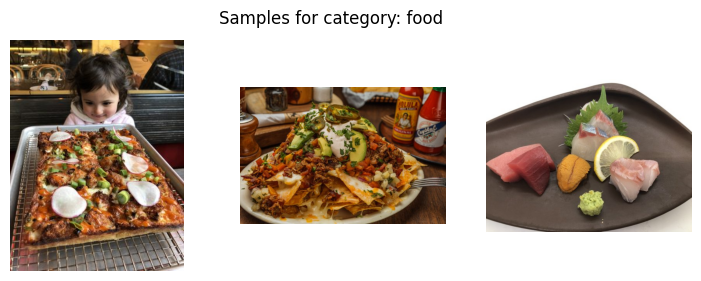

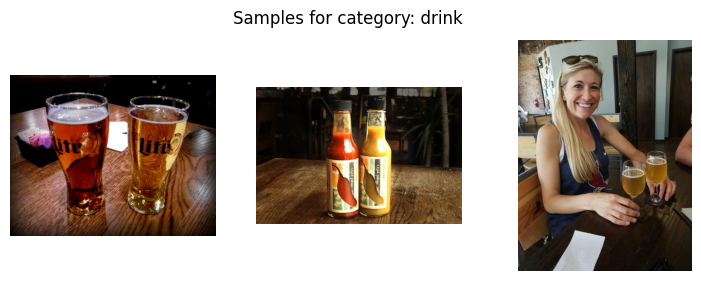

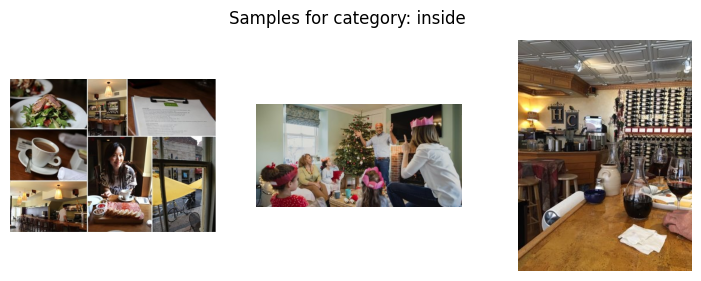

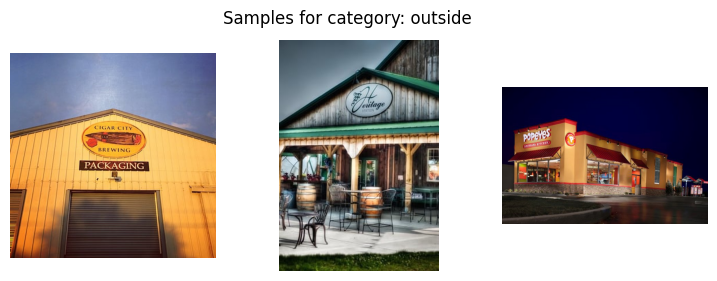

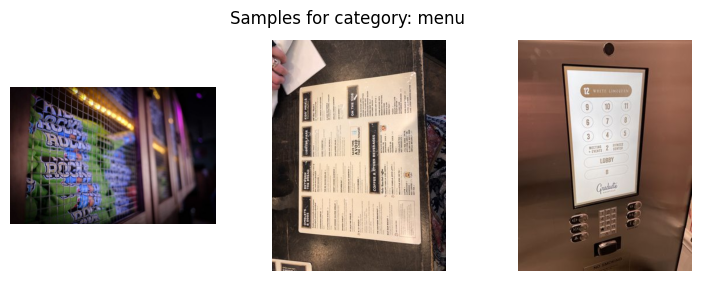

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import json
from torchvision import transforms

# Directory containing photos
# PHOTO_DIR = "/content/drive/MyDrive/Colab Notebooks/photos"

# Load the JSON file and parse it
# PHOTO_JSON = "/content/drive/MyDrive/Colab Notebooks/photos.json"
with open(PHOTO_JSON, "r") as f:
    entries = [json.loads(line) for line in f]

# Map photo_id to category for easy lookup
photo_to_category = {entry["photo_id"]: entry["label"].lower() for entry in entries}

# Function to display a few sample images per category considering the first 5,000 images
def show_samples_by_category(photo_folder, dataset, samples_per_category=3, categories=["food", "drink", "inside", "outside", "menu"], max_images=5000):
    # Group images by category based on photo_id
    category_samples = {category: [] for category in categories}

    # Loop through the dataset to map them to categories (valid images only)
    for idx in range(min(len(dataset), max_images)):
        image_name = dataset.image_files[idx]
        photo_id = image_name.split('.')[0]  # Get the photo_id (filename without extension)
        category = photo_to_category.get(photo_id, None)  # Get the category for the photo_id
        if category in categories:
            category_samples[category].append(image_name)

    # Show samples for each category
    for category in categories:
        category_images = category_samples.get(category, [])
        if category_images:
            sample_images = random.sample(category_images, min(samples_per_category, len(category_images)))
            fig, axs = plt.subplots(1, len(sample_images), figsize=(3 * len(sample_images), 3))
            fig.suptitle(f"Samples for category: {category}")
            for ax, image_filename in zip(axs, sample_images):
                img_path = os.path.join(photo_folder, image_filename)
                try:
                    img = Image.open(img_path)  # Open image as it is
                    ax.imshow(img)  # Show image in original color
                    ax.axis("off")
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
            plt.show()

# Display a few sample images per category from the first 5,000 valid images in the dataset
show_samples_by_category(PHOTO_DIR, dataset)


In [ ]:
import torch.nn as nn

# Generator Model
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Input: Latent vector (100,) → (1024, 4, 4)
            nn.ConvTranspose2d(latent_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            # (1024, 4, 4) → (512, 8, 8)
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # (512, 8, 8) → (256, 16, 16)
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (256, 16, 16) → (128, 32, 32)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 32, 32) → (3, 64, 64) (Output image, 3 channels for RGB)
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output range [-1, 1] for RGB
        )

    def forward(self, z):
        return self.model(z)

# Initialize Generator
latent_dim = 100
generator = Generator(latent_dim)
print(generator)


Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()

In [ ]:
import torch.nn as nn

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Input: (3, 64, 64) → (128, 32, 32)
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),  # Changed input channels from 1 to 3 for RGB
            nn.LeakyReLU(0.2, inplace=True),

            # (128, 32, 32) → (256, 16, 16)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (256, 16, 16) → (512, 8, 8)
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # (512, 8, 8) → (1024, 4, 4)
            nn.Conv2d(512, 1024, 4, 2, 1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            # (1024, 4, 4) → Output (1,)
            nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Output probability (0 to 1)
        )

    def forward(self, img):
        return self.model(img)

# Initialize Discriminator
discriminator = Discriminator()
print(discriminator)


Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(1024, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [ ]:
# Weight Initialization Function
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        # Initialize convolutional layers with normal distribution
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        # Initialize BatchNorm layers with normal distribution and bias constant to 0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Apply weights to Generator and Discriminator
generator.apply(weights_init)
discriminator.apply(weights_init)


Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(1024, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to device (GPU if available)
generator.to(device)
discriminator.to(device)

# Loss function for binary classification (real or fake)
criterion = nn.BCELoss()

# Set hyperparameters for the optimizers
lr = 0.0002  # Learning rate
beta1 = 0.5  # Beta1 for Adam optimizer

# Define optimizers for Generator and Discriminator
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Latent vector size for generating fake images
latent_dim = 100
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)  # Fixed noise to visualize generated images


In [ ]:
# import torch
# import os
# import json
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# from PIL import Image

# # Path to your dataset
# # PHOTO_JSON = "/content/drive/MyDrive/Colab Notebooks/photos.json"
# # PHOTO_DIR = "/content/drive/MyDrive/Colab Notebooks/photos"

# # Load the JSON file and parse it
# with open(PHOTO_JSON, "r") as f:
#     entries = [json.loads(line) for line in f]

# # Map photo_id to category for easy lookup
# photo_to_category = {entry["photo_id"]: entry["label"].lower() for entry in entries}

# class CustomDataset(Dataset):
#     def __init__(self, photo_dir, photo_to_category, transform=None):
#         self.photo_dir = photo_dir
#         self.photo_to_category = photo_to_category
#         self.transform = transform
#         self.image_filenames = os.listdir(photo_dir)  # Get all image filenames

#     def __len__(self):
#         return len(self.image_filenames)

#     def __getitem__(self, idx):
#         # Get the image file path
#         img_name = self.image_filenames[idx]
#         img_path = os.path.join(self.photo_dir, img_name)

#         # Get the photo_id (filename without extension)
#         photo_id = os.path.splitext(img_name)[0]
#         category = self.photo_to_category.get(photo_id, None)

#         # Open the image
#         image = Image.open(img_path).convert("RGB")

#         # Apply transformations (if any)
#         if self.transform:
#             image = self.transform(image)

#         # Ensure that image is a tensor and category is properly mapped
#         image = torch.tensor(image) if isinstance(image, np.ndarray) else image

#         # Return image and category (label)
#         return image, category

#     def get_image_path(self, idx):
#         """Returns the full image path for the given index."""
#         img_name = self.image_filenames[idx]
#         return os.path.join(self.photo_dir, img_name)

# # Define the image transformations (resize, normalize, etc.)
# transform = transforms.Compose([
#     transforms.Resize(64),  # Resize images to 64x64
#     transforms.CenterCrop(64),  # Crop to 64x64
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
# ])

# # Initialize the custom dataset and dataloader
# dataset = CustomDataset(photo_dir=PHOTO_DIR, photo_to_category=photo_to_category, transform=transform)
# dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


Starting Training...
Epoch [1/10], Step [0/530], Loss_D: 2.1074, Loss_G: 17.3918


UnidentifiedImageError: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/photos/VSekUmmsGZcX7KaPe_hXyw.jpg'

In [ ]:
# from PIL import Image
# import os

# def is_valid_image(file_path):
#     try:
#         with Image.open(file_path) as img:
#             img.verify()  # Verify that the image is valid
#         return True
#     except (IOError, OSError):
#         return False

# # Directory containing the images
# photo_dir = '/content/drive/MyDrive/Colab Notebooks/photos'

# # List all files in the directory (ensure you only check image files)
# all_files = os.listdir(photo_dir)

# # Limit to first 10,000 images
# image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

# # Ensure we only process up to 10,000 images
# image_files = image_files[:10000]

# corrupted_images = []

# for filename in image_files:
#     file_path = os.path.join(photo_dir, filename)

#     if not is_valid_image(file_path):
#         corrupted_images.append(filename)

# # Print out the corrupted images
# if corrupted_images:
#     print("Corrupted images found:")
#     for img in corrupted_images:
#         print(img)
# else:
#     print("No corrupted images found.")


Corrupted images found:
6bKuH4FOdaaPInF9NmlQHQ.jpg
74upe0h6XxwgzqpdnAh_7Q.jpg
9BvYOtforBBP6MvvDogtmw.jpg
9jBH61ndIcsheo6FtIHArA.jpg
amM65inTV6wvx0NNZN5qhg.jpg
ARwqGQZaT0p-XpYYjMXgQg.jpg
C6n0nKVbgLbYmxSiQ_bFsg.jpg
CA9z96gGA4y9QOes2Y9eGw.jpg


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from torch.utils.data import DataLoader

# Training parameters
epochs = 10
real_label = 1.0
fake_label = 0.0

# Track losses
G_losses = []
D_losses = []

print("Starting Training...")

# Set the device (CUDA or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure the models are on the correct device
generator.to(device)
discriminator.to(device)

# Create a new folder to save images
os.makedirs("/content/drive/MyDrive/Colab Notebooks/dcgan", exist_ok=True)

# Create the DataLoader from the already created dataset in Step 1
# We use 'dataset' directly without needing to re-filter images
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

# Print the size of the dataset
print(f"Dataset size: {len(dataset)}")

# Start the training loop
for epoch in range(epochs):
    start_time = time.time()

    for i, data in enumerate(dataloader):  # Adjusted to unpack correctly based on dataset return
        # Check if dataset returns both images and labels or just images
        if isinstance(data, tuple) and len(data) == 2:
            real_images, _ = data  # If dataset returns both images and labels
        else:
            real_images = data  # If dataset returns only images

        # Move real images to device
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Create labels for real and fake images
        real_labels = torch.full((batch_size,), real_label, dtype=torch.float, device=device)
        fake_labels = torch.full((batch_size,), fake_label, dtype=torch.float, device=device)

        # -------------------------
        #  Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()

        # Real images loss
        output_real = discriminator(real_images).view(-1)
        loss_real = criterion(output_real, real_labels)

        # Fake images loss
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)
        output_fake = discriminator(fake_images.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        # Combine losses and update discriminator
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        #  Train Generator
        # -------------------------
        optimizer_G.zero_grad()

        # Generate fake images and get discriminator output
        output_G = discriminator(fake_images).view(-1)
        loss_G = criterion(output_G, real_labels)  # Trick discriminator into thinking they're real

        # Update generator
        loss_G.backward()
        optimizer_G.step()

        # Store losses
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        # Print training status
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i}/{len(dataloader)}], Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}")

    # Generate and save sample images for every epoch
    with torch.no_grad():
        fake_images = generator(fixed_noise).cpu().detach()
        fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))
        for j in range(4):
            ax[j].imshow((fake_images[j].permute(1, 2, 0) + 1) / 2)  # Rescale to [0, 1] range
            ax[j].axis("off")
        # Save sample images in the new folder 'dcgan'
        plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/dcgan/sample_epoch_{epoch+1}.png")
        plt.close()

    print(f"Epoch {epoch+1} completed in {time.time() - start_time:.2f} seconds.")

# Save final models
torch.save(generator.state_dict(), "/content/drive/MyDrive/Colab Notebooks/dcgan/dcgan_generator.pth")
torch.save(discriminator.state_dict(), "/content/drive/MyDrive/Colab Notebooks/dcgan/dcgan_discriminator.pth")


Starting Training...
Dataset size: 4996
Epoch [1/10], Step [0/79], Loss_D: 2.2781, Loss_G: 5.3639
Epoch 1 completed in 3344.51 seconds.
Epoch [2/10], Step [0/79], Loss_D: 0.0001, Loss_G: 56.4024
Epoch 2 completed in 3403.53 seconds.
Epoch [3/10], Step [0/79], Loss_D: 0.0001, Loss_G: 56.3326
Epoch 3 completed in 2482.14 seconds.
Epoch [4/10], Step [0/79], Loss_D: 0.0001, Loss_G: 56.2538
Epoch 4 completed in 2385.04 seconds.
Epoch [5/10], Step [0/79], Loss_D: 0.0000, Loss_G: 55.8973
Epoch 5 completed in 2044.80 seconds.
Epoch [6/10], Step [0/79], Loss_D: 0.0001, Loss_G: 56.0328
Epoch 6 completed in 2207.46 seconds.
Epoch [7/10], Step [0/79], Loss_D: 0.0000, Loss_G: 55.7035
Epoch 7 completed in 1996.23 seconds.
Epoch [8/10], Step [0/79], Loss_D: 0.0000, Loss_G: 55.9234
Epoch 8 completed in 2167.92 seconds.
Epoch [9/10], Step [0/79], Loss_D: 0.0001, Loss_G: 55.7297
Epoch 9 completed in 1977.71 seconds.
Epoch [10/10], Step [0/79], Loss_D: 0.0000, Loss_G: 55.3871
Epoch 10 completed in 1691.0

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import inception_v3
import numpy as np
from scipy.stats import entropy

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained InceptionV3 model
inception = inception_v3(pretrained=True, transform_input=True).eval().to(device)

# Define function to compute Inception Score
def calculate_inception_score(generator, num_images=500, latent_dim=100, batch_size=50):
    # Transformation: Resize to InceptionV3 input size and normalize for RGB images
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # Resize to InceptionV3 input size
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize for RGB images
    ])

    def get_inception_preds(images):
        with torch.no_grad():
            preds = inception(images)
            return F.softmax(preds, dim=1)

    fake_images = []
    with torch.no_grad():
        for _ in range(num_images // batch_size):
            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            generated_images = generator(noise).cpu()

            # Convert images from [-1, 1] to [0, 1]
            generated_images = (generated_images + 1) / 2

            # Apply the transformation (resize and normalization)
            transformed_images = torch.stack([transform(img) for img in generated_images])
            fake_images.append(transformed_images)

    fake_images = torch.cat(fake_images).to(device)
    pred_probs = []

    # Get predictions for all generated images
    for i in range(0, fake_images.size(0), batch_size):
        batch = fake_images[i:i+batch_size]
        pred_probs.append(get_inception_preds(batch))

    pred_probs = torch.cat(pred_probs, dim=0)

    # Calculate Inception Score (IS)
    p_y = pred_probs.mean(dim=0)  # Mean of predicted probabilities
    kl_div = [entropy(pred_probs[i].cpu().numpy(), p_y.cpu().numpy()) for i in range(pred_probs.size(0))]

    kl_div = np.array(kl_div)
    is_mean = np.exp(np.mean(kl_div))
    is_std = np.exp(np.std(kl_div))

    return is_mean, is_std

# Compute and print IS
is_mean, is_std = calculate_inception_score(generator)
print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")


Inception Score: 1.1249 ± 1.0831


In [ ]:
import torch
from torch import nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from scipy.linalg import sqrtm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Preprocessing function to resize and normalize images
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # Resize all images to 299x299
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
    ])
    return transform(image).unsqueeze(0)  # Add batch dimension

# Load InceptionV3 model for feature extraction
inception_model = models.inception_v3(weights="IMAGENET1K_V1")  # Update as per the new API
inception_model.fc = nn.Identity()  # Remove classification layer
inception_model = inception_model.eval().to(device)  # Move to GPU/CPU

# Function to extract features
def extract_features(image, model):
    image = preprocess_image(image).to(device)
    with torch.no_grad():
        features = model(image)  # Extract features
    return features.view(features.size(0), -1)  # Flatten output

# Function to calculate mean and covariance (flatten features to 2D)
def calculate_mean_and_cov(features):
    features = np.array(features)  # Convert to numpy
    if features.ndim > 2:
        features = features.reshape(features.shape[0], -1)  # Flatten to 2D (n_samples, n_features)
    mean = np.mean(features, axis=0)  # Compute mean
    covariance = np.cov(features, rowvar=False)  # Compute covariance
    return mean, covariance

# Function to compute FID Score
def calculate_fid_score(real_features, fake_features):
    real_mean, real_cov = calculate_mean_and_cov(real_features)
    fake_mean, fake_cov = calculate_mean_and_cov(fake_features)

    mean_diff = np.sum((real_mean - fake_mean) ** 2)
    cov_sqrt, _ = sqrtm(real_cov.dot(fake_cov), disp=False)
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    trace_cov = np.trace(real_cov + fake_cov - 2 * cov_sqrt)

    fid_score = mean_diff + trace_cov
    return fid_score

# Assuming 'dataset' contains valid image paths or image objects
# If dataset contains paths, load images
real_images = []

for image_path in dataset:  # Dataset variable contains paths or image objects
    if isinstance(image_path, str):  # If it's a path, load the image
        try:
            with Image.open(image_path) as img:
                if img.mode != "RGB":  # Convert to RGB if necessary
                    img = img.convert("RGB")
                real_images.append(extract_features(img, inception_model))
        except Exception as e:
            print(f"Skipping corrupted image: {image_path} | Error: {e}")
    else:
        # If it's already a tensor (torch.Tensor), convert it to PIL Image first
        if isinstance(image_path, torch.Tensor):
            image_path = transforms.ToPILImage()(image_path.cpu().detach())  # Convert tensor to PIL Image
        real_images.append(extract_features(image_path, inception_model))

# Generate fake images (as before)
num_images = 5000  # You can adjust this if needed
latent_dim = 100
fake_images = []

for _ in range(num_images):
    noise = torch.randn(1, latent_dim, 1, 1, device=device)
    fake_image = generator(noise).cpu().detach().squeeze(0)

    # Normalize fake image for visualization
    fake_image = (fake_image - fake_image.min()) / (fake_image.max() - fake_image.min())

    # Convert to PIL Image
    fake_image_pil = transforms.ToPILImage()(fake_image)
    fake_images.append(extract_features(fake_image_pil, inception_model))

# Convert feature lists to arrays
real_features = np.array([f.cpu().numpy() for f in real_images])
fake_features = np.array([f.cpu().numpy() for f in fake_images])

# Compute and print FID Score
fid_score = calculate_fid_score(real_features, fake_features)
print(f"FID Score: {fid_score:.4f}")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 121MB/s] 


NameError: name 'dataset' is not defined

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# Assume your generator model is ready
# Define number of images to generate
num_images = 500
latent_dim = 100  # Latent vector dimension (adjust based on your model)

# Generate fake images (replace this with your actual generator's output)
fake_images_generated = []
for _ in range(num_images):
    noise = torch.randn(1, latent_dim, 1, 1, device=device)  # Latent vector for one image
    fake_image = generator(noise).cpu().detach().squeeze(0)  # Generate fake image
    fake_image_pil = transforms.ToPILImage()(fake_image)
    fake_images_generated.append(fake_image_pil)

# Get the last 5 images generated
final_5_images = fake_images_generated[-5:]

# Display the last 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, img in zip(axes, final_5_images):
    ax.imshow(img)
    ax.axis('off')
plt.show()

# Save the last 5 images
save_dir = "generated_images"
os.makedirs(save_dir, exist_ok=True)

for i, img in enumerate(final_5_images):
    img.save(os.path.join(save_dir, f"generated_image_{i+1}.png"))
    print(f"Saved generated_image_{i+1}.png")
